In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')


# Default Correlation Graphs

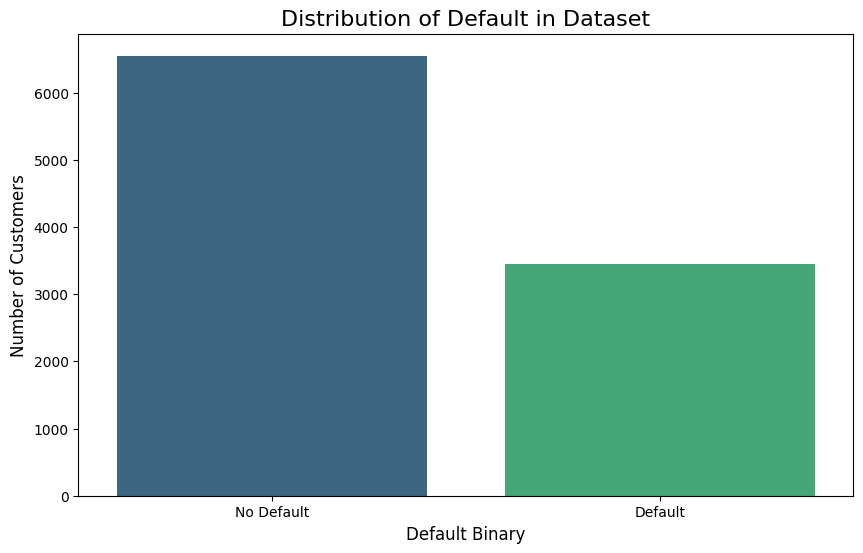

In [3]:
# 1. Update the map (assuming 0=No, 1=Yes)
default_map = {0: "No Default", 1: "Default"}
df["default_label"] = df["Defaulted"].map(default_map)

# 2. Updated Plotting Code
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x="default_label", 
    hue="default_label", # Fixed the Futurewarding by assigning hue
    palette="viridis", 
    order=["No Default", "Default"],
    legend=False 
)

plt.title("Distribution of Default in Dataset", fontsize=16)
plt.xlabel("Default Binary", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.show()

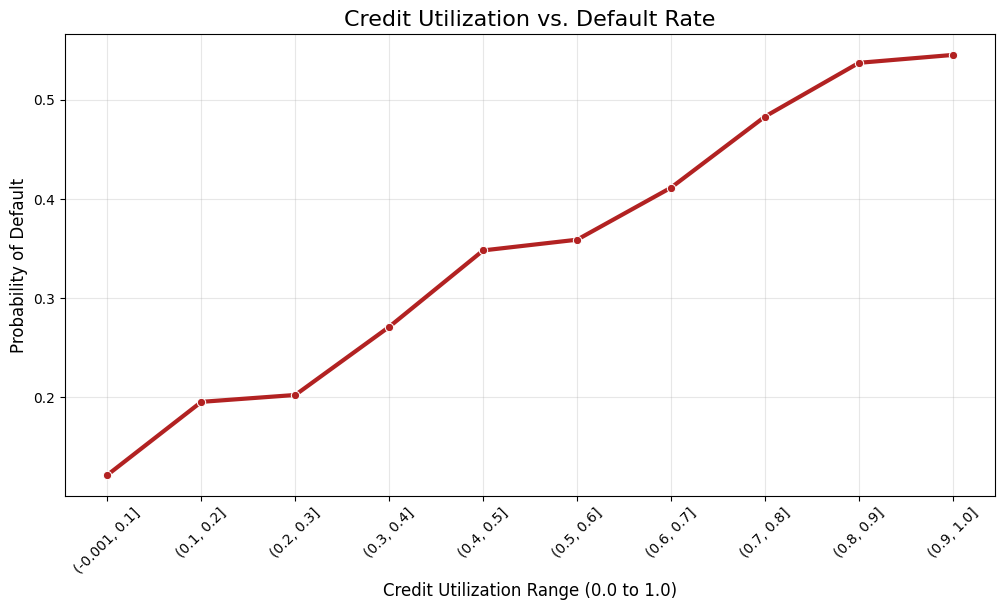

In [14]:
# 1. Create Utilization Bins (Grouping makes the correlation much clearer)
df['util_bins'] = pd.cut(df['Credit_Utilization_Ratio'], bins=10)

# 2. Calculate the mean default rate per bin
util_trend = df.groupby('util_bins', observed=True)['Defaulted'].mean().reset_index()

# 3. Convert the bins to strings for the x-axis
util_trend['util_bins'] = util_trend['util_bins'].astype(str)

# 4. Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=util_trend, x='util_bins', y='Defaulted', marker='o', color='firebrick', linewidth=3)

plt.title('Credit Utilization vs. Default Rate', fontsize=16)
plt.xlabel('Credit Utilization Range (0.0 to 1.0)', fontsize=12)
plt.ylabel('Probability of Default', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

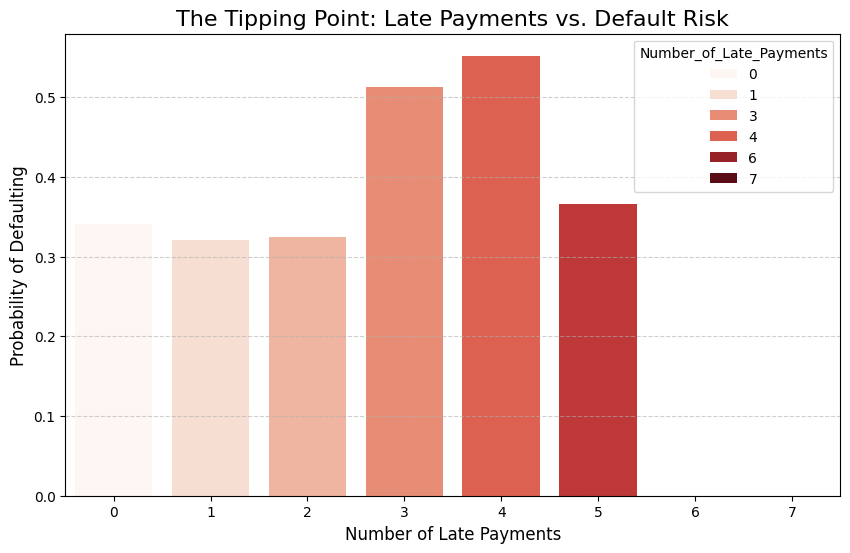

In [12]:
# 1. Group total transactions into 8 clean bins/ranges
df['Total_Transactions_Bins'] = pd.cut(df['Total_Transactions'], bins=8)

# 2. Calculate average fraud occurrences for each bin
fraud_trend = df.groupby('Total_Transactions_Bins', observed=True)['Fraud_Transactions'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fraud_trend, 
    x=fraud_trend['Total_Transactions_Bins'].astype(str), 
    y='Fraud_Transactions', 
    marker='o', 
    color='darkorange', 
    linewidth=3
)

plt.title('Total Transactions vs. Average Fraud Occurrences', fontsize=16)
plt.xlabel('Range of Total Transactions (Low to High)', fontsize=12)
plt.ylabel('Average Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Spend/Credit Correlation Graphs

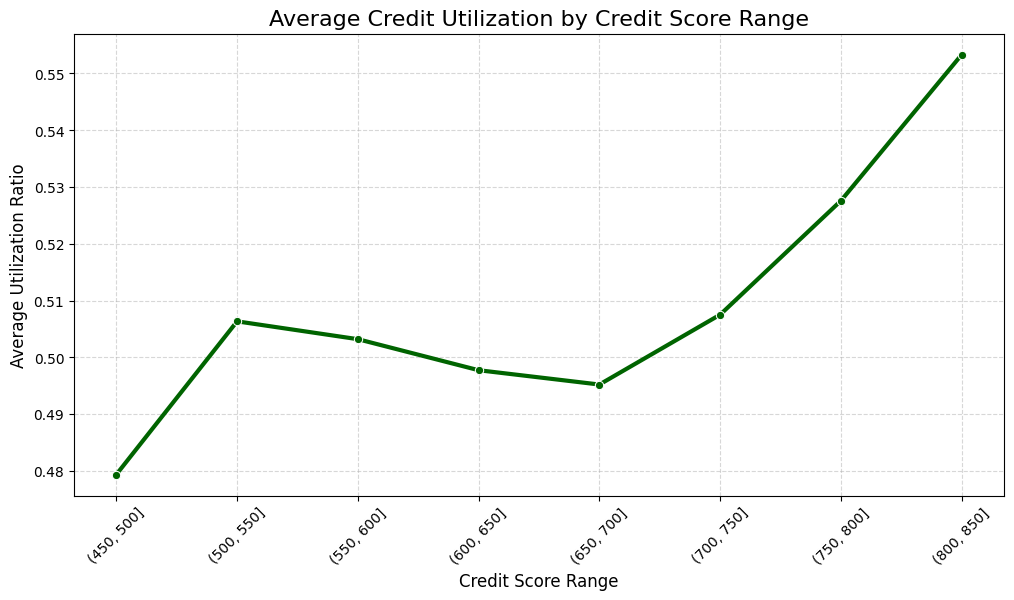

In [10]:
# 1. Create Credit Score Bins (e.g., in steps of 50)
score_bins = [450, 500, 550, 600, 650, 700, 750, 800, 850]
df['score_range'] = pd.cut(df['Credit_Score'], bins=score_bins)

# 2. Calculate the mean utilization for each score range
score_trend = df.groupby('score_range', observed=True)['Credit_Utilization_Ratio'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=score_trend, 
    x=score_trend['score_range'].astype(str), 
    y='Credit_Utilization_Ratio', 
    marker='o', 
    linewidth=3, 
    color='darkgreen'
)

plt.title('Average Credit Utilization by Credit Score Range', fontsize=16)
plt.xlabel('Credit Score Range', fontsize=12)
plt.ylabel('Average Utilization Ratio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

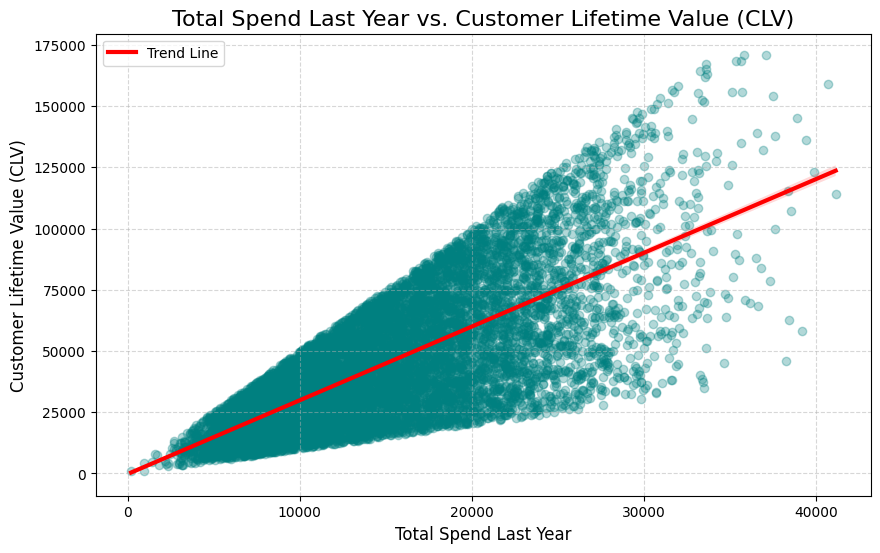

In [6]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df, 
    x='Total_Spend_Last_Year', 
    y='CLV',
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 3, 'label': 'Trend Line'}
)

plt.title('Total Spend Last Year vs. Customer Lifetime Value (CLV)', fontsize=16)
plt.xlabel('Total Spend Last Year', fontsize=12)
plt.ylabel('Customer Lifetime Value (CLV)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

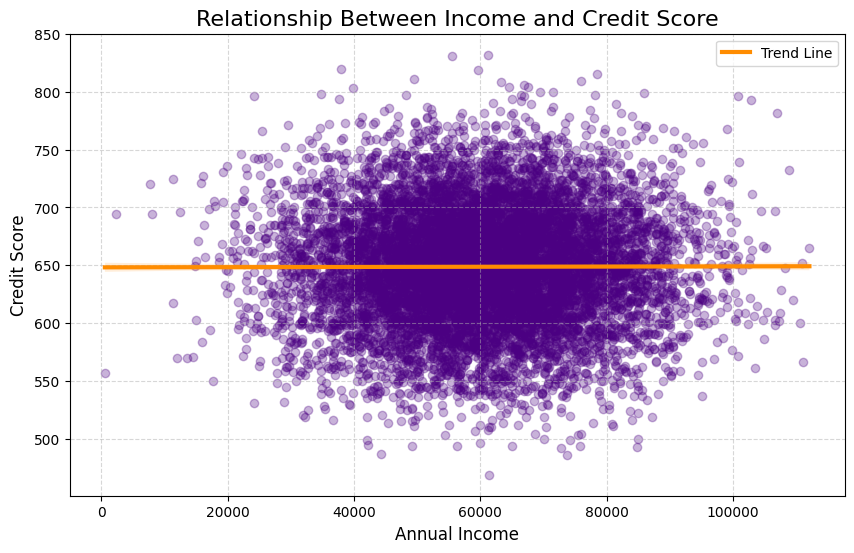

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 2. Create the plot
plt.figure(figsize=(10, 6))

# A scatter plot with a regression line to show the trend
sns.regplot(
    data=df, 
    x='Annual_Income', 
    y='Credit_Score',
    scatter_kws={'alpha': 0.3, 'color': 'indigo'}, # The 'alpha' makes dots transparent so we can see dense clusters
    line_kws={'color': 'darkorange', 'linewidth': 3, 'label': 'Trend Line'}
)

plt.title('Relationship Between Income and Credit Score', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Display the plot
plt.show()

# Fraud Correlation Graphs

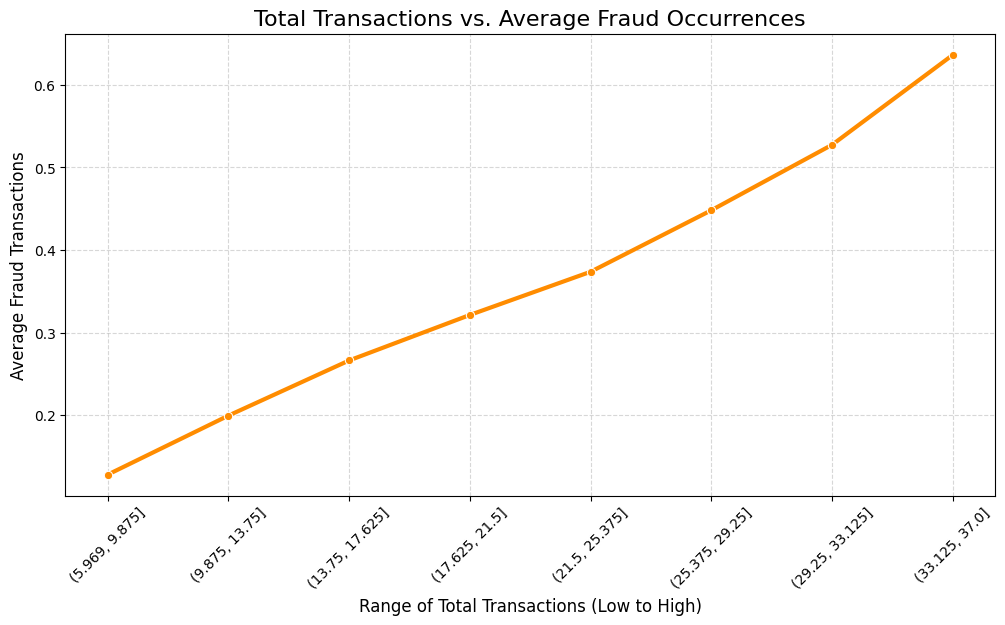

In [15]:
# 1. Group total transactions into 8 clean bins/ranges
df['Total_Transactions_Bins'] = pd.cut(df['Total_Transactions'], bins=8)

# 2. Calculate average fraud occurrences for each bin
fraud_trend = df.groupby('Total_Transactions_Bins', observed=True)['Fraud_Transactions'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fraud_trend, 
    x=fraud_trend['Total_Transactions_Bins'].astype(str), 
    y='Fraud_Transactions', 
    marker='o', 
    color='darkorange', 
    linewidth=3
)

plt.title('Total Transactions vs. Average Fraud Occurrences', fontsize=16)
plt.xlabel('Range of Total Transactions (Low to High)', fontsize=12)
plt.ylabel('Average Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

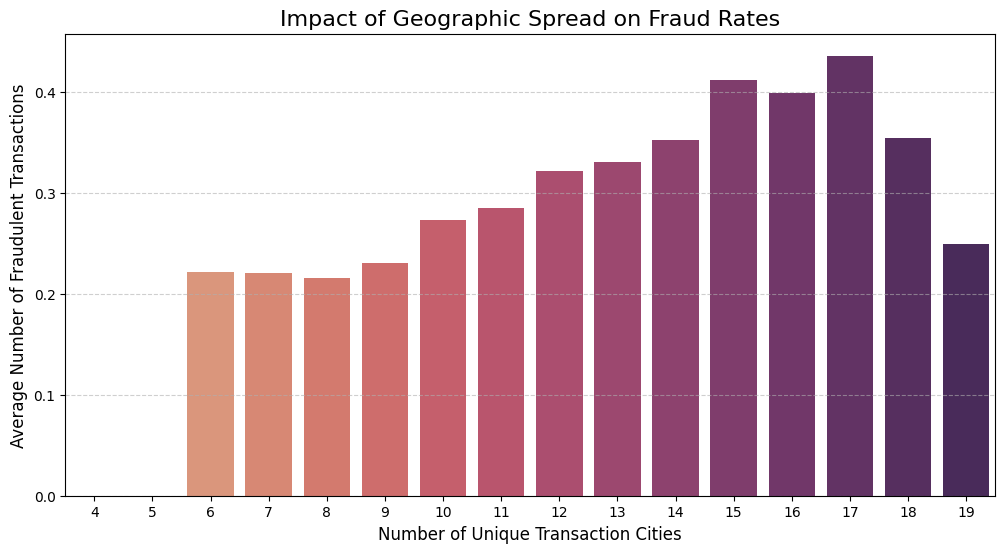

In [16]:
# 1. Group by the number of unique cities and calculate the average fraud rate
city_fraud_trend = df.groupby('Unique_Transaction_Cities')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk perfectly
sns.barplot(
    data=city_fraud_trend, 
    x='Unique_Transaction_Cities', 
    y='Fraud_Transactions', 
    palette='flare',      # 'flare' or 'Reds' works great for fraud/danger
    hue='Unique_Transaction_Cities',
    legend=False
)

plt.title('Impact of Geographic Spread on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Transaction Cities', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

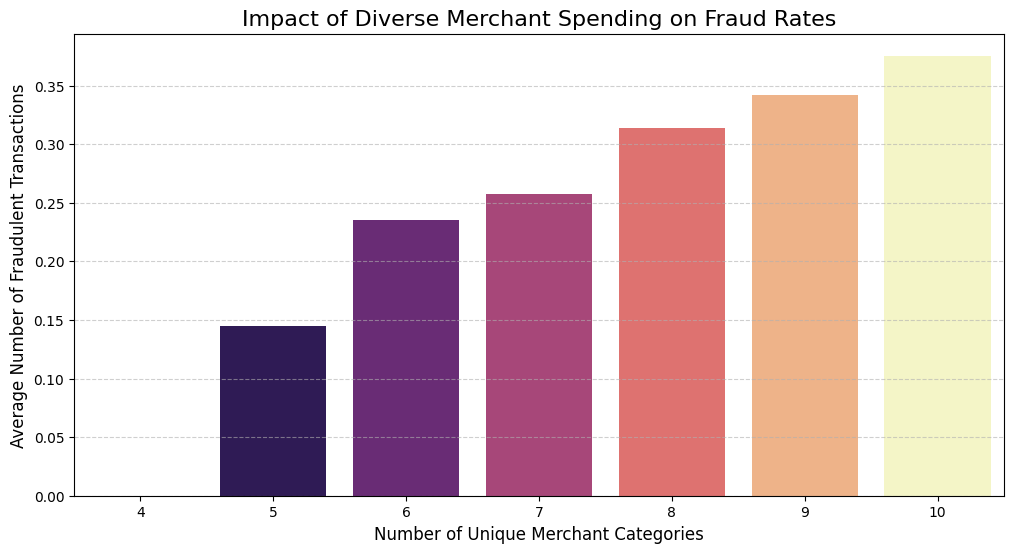

In [17]:
# 1. Group by the number of unique merchant categories and calculate the average fraud rate
category_fraud_trend = df.groupby('Unique_Merchant_Categories')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk
ax = sns.barplot(
    data=category_fraud_trend, 
    x='Unique_Merchant_Categories', 
    y='Fraud_Transactions', 
    palette='magma',      # 'magma' gives a great dark-to-light progression
    hue='Unique_Merchant_Categories'
)

# Clean up the legend (if one accidentally appears)
if ax.get_legend():
    ax.get_legend().remove()

plt.title('Impact of Diverse Merchant Spending on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Merchant Categories', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# K Means Cluster Graphs

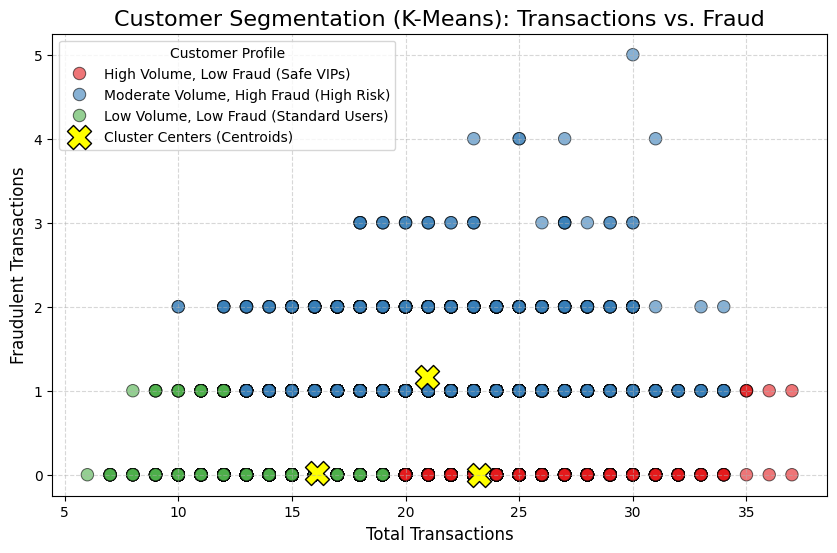

--- Average Values per Customer Segment ---
                                         Total_Transactions  \
Customer_Segment                                              
High Volume, Low Fraud (Safe VIPs)                23.229658   
Low Volume, Low Fraud (Standard Users)            16.089909   
Moderate Volume, High Fraud (High Risk)           20.938088   

                                         Fraud_Transactions  
Customer_Segment                                             
High Volume, Low Fraud (Safe VIPs)                 0.001389  
Low Volume, Low Fraud (Standard Users)             0.016772  
Moderate Volume, High Fraud (High Risk)            1.167994  


In [4]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Select the features for clustering
features = ['Total_Transactions', 'Fraud_Transactions']
X = df[features]

# 4. Scale the data
# K-Means calculates physical distance between points. We MUST scale the data 
# so 'Total_Transactions' (which can be 30+) doesn't mathematically overpower 
# 'Fraud_Transactions' (which is usually 0-5).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Build the K-Means Model
# We set n_clusters=3 to create 3 distinct "Customer Segments"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Map the clusters to meaningful business names
segment_names = {
    0: 'High Volume, Low Fraud (Safe VIPs)', 
    1: 'Moderate Volume, High Fraud (High Risk)', 
    2: 'Low Volume, Low Fraud (Standard Users)'
}
df['Customer_Segment'] = df['Cluster'].map(segment_names)

# 6. VISUALIZATION: The Scatter Plot
plt.figure(figsize=(10, 6))

# Plot the individual customers
sns.scatterplot(
    data=df,
    x='Total_Transactions',
    y='Fraud_Transactions',
    hue='Customer_Segment',
    palette='Set1',
    s=80,      # Size of the dots
    alpha=0.6, # Transparency to see overlapping points
    edgecolor='black'
)

# 7. Add the Cluster Centers (The "Centroids")
# We have to reverse the scaling so the "X" marks show up on the correct normal numbers
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_unscaled[:, 0], 
    centers_unscaled[:, 1], 
    c='yellow', 
    s=300, 
    marker='X', 
    edgecolor='black', 
    label='Cluster Centers (Centroids)'
)

plt.title('Customer Segmentation (K-Means): Transactions vs. Fraud', fontsize=16)
plt.xlabel('Total Transactions', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Profile')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 8. Print the averages for each cluster for your report!
print("--- Average Values per Customer Segment ---")
print(df.groupby('Customer_Segment')[features].mean())